# 04 - DINOv2 ViT-B/14 (general SSL)

Trains **DINOv2 ViT-B/14 (general SSL)** on cached fundus crops with the frozen 5-fold splits; reports per-bigclass one-vs-rest AUC (Fig 2a style), macro AUC and frequency-weighted F1. All logic lives in `fundus_lib`.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, glob
# auto-locate the folder that actually contains fundus_lib
hits = glob.glob("/content/drive/MyDrive/**/fundus_lib/__init__.py", recursive=True)
assert hits, "fundus_lib not found anywhere under MyDrive — check the upload"
PROJECT_DIR = os.path.dirname(os.path.dirname(hits[0]))
print("PROJECT_DIR ->", PROJECT_DIR)

DATA_ROOT   = os.path.join(PROJECT_DIR, "1000images")
CACHE_DIR   = os.path.join(PROJECT_DIR, "cache_crops")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
MANIFEST    = os.path.join(PROJECT_DIR, "manifest_cached.json")
SPLITS      = os.path.join(PROJECT_DIR, "splits.json")
os.makedirs(RESULTS_DIR, exist_ok=True)

%pip install -q timm transformers torchinfo grad-cam

sys.path.insert(0, PROJECT_DIR)
import fundus_lib as fl
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| imported fundus_lib OK")


Mounted at /content/drive
PROJECT_DIR -> /content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 114.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
device: cuda | imported fundus_lib OK


## Load frozen manifest + splits

In [3]:
import json, numpy as np
manifest = json.load(open(MANIFEST))
splits   = fl.data.load_splits(SPLITS)
folds    = np.array(splits["fold_of_index"])
MODEL_NAME = "dinov2"
EPOCHS = 100
BATCH = 16
c2i, i2c = fl.data.class_index_maps(range(10))
NUM_CLASSES = len(c2i)
train_tf, eval_tf = fl.models.get_transforms(MODEL_NAME)
print("model:", MODEL_NAME, "| classes:", NUM_CLASSES)

model: dinov2 | classes: 10


## 5-fold cross-validation

In [4]:
from torch.utils.data import DataLoader
fold_metrics, all_true, all_prob, histories = [], [], [], []
for test_fold in range(splits["n_splits"]):
    tr_idx, va_idx, te_idx = fl.data.fold_indices(folds, test_fold)
    ds_tr = fl.data.FundusDataset(manifest, tr_idx, train_tf, c2i)
    ds_va = fl.data.FundusDataset(manifest, va_idx, eval_tf, c2i)
    ds_te = fl.data.FundusDataset(manifest, te_idx, eval_tf, c2i)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True, num_workers=2)
    dl_va = DataLoader(ds_va, batch_size=BATCH, shuffle=False, num_workers=2)
    dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2)
    tr_labels = [c2i[manifest[i]["bigclass"]] for i in tr_idx]
    cw = fl.engine.class_weights_from_labels(tr_labels, NUM_CLASSES, device)
    model = fl.models.build_model(MODEL_NAME, NUM_CLASSES)
    print(f"\n=== fold {test_fold} | train {len(tr_idx)} val {len(va_idx)} test {len(te_idx)} ===")
    model, hist = fl.engine.fit(model, dl_tr, dl_va, device, NUM_CLASSES,
                                epochs=EPOCHS, class_weights=cw, verbose=True)
    yt, yp = fl.engine.evaluate(model, dl_te, device)
    m = fl.metrics.compute_metrics(yt, yp, index_to_class=i2c)
    print("  fold %d: wF1=%.3f macroAUC=%.3f wAUC=%.3f" % (test_fold, m["weighted_f1"], m["macro_auc"], m["weighted_auc"]))
    fold_metrics.append(m); all_true.append(yt); all_prob.append(yp); histories.append(hist)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


=== fold 0 | train 330 val 110 test 111 ===


/content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/engine.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None


  epoch  0 | train_loss 3.3657 val_loss 2.5129 | train_acc 0.133 val_acc 0.091 | val_wF1 0.0152
  epoch  1 | train_loss 2.4309 val_loss 2.4003 | train_acc 0.094 val_acc 0.155 | val_wF1 0.0498
  epoch  2 | train_loss 2.4334 val_loss 2.3150 | train_acc 0.085 val_acc 0.100 | val_wF1 0.0424
  epoch  3 | train_loss 2.3552 val_loss 2.1525 | train_acc 0.091 val_acc 0.282 | val_wF1 0.1575
  epoch  4 | train_loss 2.2696 val_loss 2.2224 | train_acc 0.173 val_acc 0.218 | val_wF1 0.1252
  epoch  5 | train_loss 2.3448 val_loss 2.1826 | train_acc 0.127 val_acc 0.227 | val_wF1 0.1563
  epoch  6 | train_loss 2.1910 val_loss 2.1536 | train_acc 0.215 val_acc 0.218 | val_wF1 0.1080
  epoch  7 | train_loss 2.1412 val_loss 2.0434 | train_acc 0.242 val_acc 0.236 | val_wF1 0.1945
  epoch  8 | train_loss 2.1868 val_loss 2.0084 | train_acc 0.212 val_acc 0.318 | val_wF1 0.2364
  epoch  9 | train_loss 2.1522 val_loss 1.9774 | train_acc 0.248 val_acc 0.382 | val_wF1 0.2744
  epoch 10 | train_loss 2.1106 val_loss 

...

  epoch  0 | train_loss 3.2063 val_loss 2.6166 | train_acc 0.139 val_acc 0.118 | val_wF1 0.0250
  epoch  1 | train_loss 2.4660 val_loss 2.3785 | train_acc 0.066 val_acc 0.100 | val_wF1 0.0182
  epoch  2 | train_loss 2.4771 val_loss 2.4755 | train_acc 0.066 val_acc 0.055 | val_wF1 0.0056
  epoch  3 | train_loss 2.3964 val_loss 2.2967 | train_acc 0.151 val_acc 0.173 | val_wF1 0.0636
  epoch  4 | train_loss 2.2604 val_loss 2.2228 | train_acc 0.118 val_acc 0.100 | val_wF1 0.0614
  epoch  5 | train_loss 2.2566 val_loss 2.1796 | train_acc 0.172 val_acc 0.173 | val_wF1 0.1110
  epoch  6 | train_loss 2.1938 val_loss 2.1290 | train_acc 0.199 val_acc 0.245 | val_wF1 0.1482
  epoch  7 | train_loss 2.2284 val_loss 2.2936 | train_acc 0.239 val_acc 0.173 | val_wF1 0.1666
  epoch  8 | train_loss 2.2232 val_loss 2.1030 | train_acc 0.224 val_acc 0.264 | val_wF1 0.2302
  epoch  9 | train_loss 2.1363 val_loss 2.1399 | train_acc 0.239 val_acc 0.218 | val_wF1 0.2003
  epoch 10 | train_loss 2.1457 val_loss 

/content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/engine.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None


  epoch  0 | train_loss 3.4428 val_loss 2.3389 | train_acc 0.079 val_acc 0.209 | val_wF1 0.0723
  epoch  1 | train_loss 2.4922 val_loss 2.4560 | train_acc 0.151 val_acc 0.045 | val_wF1 0.0040
  epoch  2 | train_loss 2.4004 val_loss 2.4034 | train_acc 0.100 val_acc 0.100 | val_wF1 0.0182
  epoch  3 | train_loss 2.4117 val_loss 2.3568 | train_acc 0.103 val_acc 0.191 | val_wF1 0.0962
  epoch  4 | train_loss 2.2532 val_loss 2.2882 | train_acc 0.190 val_acc 0.245 | val_wF1 0.1453
  epoch  5 | train_loss 2.2470 val_loss 2.2487 | train_acc 0.145 val_acc 0.127 | val_wF1 0.0367
  epoch  6 | train_loss 2.3185 val_loss 2.1579 | train_acc 0.178 val_acc 0.191 | val_wF1 0.1267
  epoch  7 | train_loss 2.2291 val_loss 2.1693 | train_acc 0.196 val_acc 0.164 | val_wF1 0.0875
  epoch  8 | train_loss 2.1805 val_loss 2.1772 | train_acc 0.245 val_acc 0.091 | val_wF1 0.0948
  epoch  9 | train_loss 2.1933 val_loss 2.0594 | train_acc 0.163 val_acc 0.273 | val_wF1 0.1914
  epoch 10 | train_loss 2.1532 val_loss 

/content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/engine.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None


  epoch  0 | train_loss 3.1287 val_loss 2.6129 | train_acc 0.094 val_acc 0.027 | val_wF1 0.0014
  epoch  1 | train_loss 2.5057 val_loss 2.3517 | train_acc 0.052 val_acc 0.144 | val_wF1 0.0409
  epoch  2 | train_loss 2.3803 val_loss 2.3356 | train_acc 0.088 val_acc 0.045 | val_wF1 0.0039
  epoch  3 | train_loss 2.3607 val_loss 2.3472 | train_acc 0.067 val_acc 0.117 | val_wF1 0.0273
  epoch  4 | train_loss 2.4283 val_loss 2.1937 | train_acc 0.130 val_acc 0.243 | val_wF1 0.1152
  epoch  5 | train_loss 2.2830 val_loss 2.1689 | train_acc 0.155 val_acc 0.135 | val_wF1 0.0732
  epoch  6 | train_loss 2.2868 val_loss 2.2093 | train_acc 0.148 val_acc 0.117 | val_wF1 0.0784
  epoch  7 | train_loss 2.3083 val_loss 2.2960 | train_acc 0.136 val_acc 0.207 | val_wF1 0.1181
  epoch  8 | train_loss 2.3083 val_loss 2.0669 | train_acc 0.133 val_acc 0.171 | val_wF1 0.0942
  epoch  9 | train_loss 2.1363 val_loss 2.1664 | train_acc 0.224 val_acc 0.144 | val_wF1 0.1316
  epoch 10 | train_loss 2.2112 val_loss 

## Aggregate + save

In [5]:
import numpy as np, json, torch
summary = fl.metrics.aggregate_folds(fold_metrics)
print("=== %s : 5-fold summary ===" % MODEL_NAME)
for k in ["weighted_auc","macro_auc","weighted_f1","macro_f1","balanced_accuracy","accuracy"]:
    print("  %-20s %.3f +/- %.3f" % (k, summary[k+"_mean"], summary[k+"_std"]))
pooled = fl.metrics.compute_metrics(np.concatenate(all_true), np.concatenate(all_prob), i2c)
out = {"model": MODEL_NAME, "summary": summary,
       "per_fold": [{k:v for k,v in m.items() if not isinstance(v,dict)} for m in fold_metrics],
       "per_class_auc_pooled": pooled["per_class_auc"]}
json.dump(out, open(os.path.join(RESULTS_DIR, "metrics_%s.json" % MODEL_NAME), "w"), indent=2)
np.savez(os.path.join(RESULTS_DIR, "preds_%s.npz" % MODEL_NAME),
         y_true=np.concatenate(all_true), y_prob=np.concatenate(all_prob))
json.dump(histories, open(os.path.join(RESULTS_DIR, "history_%s.json" % MODEL_NAME), "w"), indent=2)
# also save last fold weights so the grad-cam cells can reload after restart
torch.save(model.state_dict(), os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % MODEL_NAME))
print("saved metrics_%s.json, preds_%s.npz, history_%s.json, weights_%s_last_fold.pth"
      % (MODEL_NAME, MODEL_NAME, MODEL_NAME, MODEL_NAME))


=== dinov2 : 5-fold summary ===
  weighted_auc         0.910 +/- 0.014
  macro_auc            0.899 +/- 0.016
  weighted_f1          0.611 +/- 0.046
  macro_f1             0.548 +/- 0.053
  balanced_accuracy    0.556 +/- 0.054
  accuracy             0.610 +/- 0.050
saved metrics_dinov2.json, preds_dinov2.npz, history_dinov2.json, weights_dinov2_last_fold.pth


## Visualize: training curves + per-disease ROC (Fig 2a-style)

Loss/accuracy curves from `history_dinov2.json`; ROC curves from pooled `preds_dinov2.npz`.


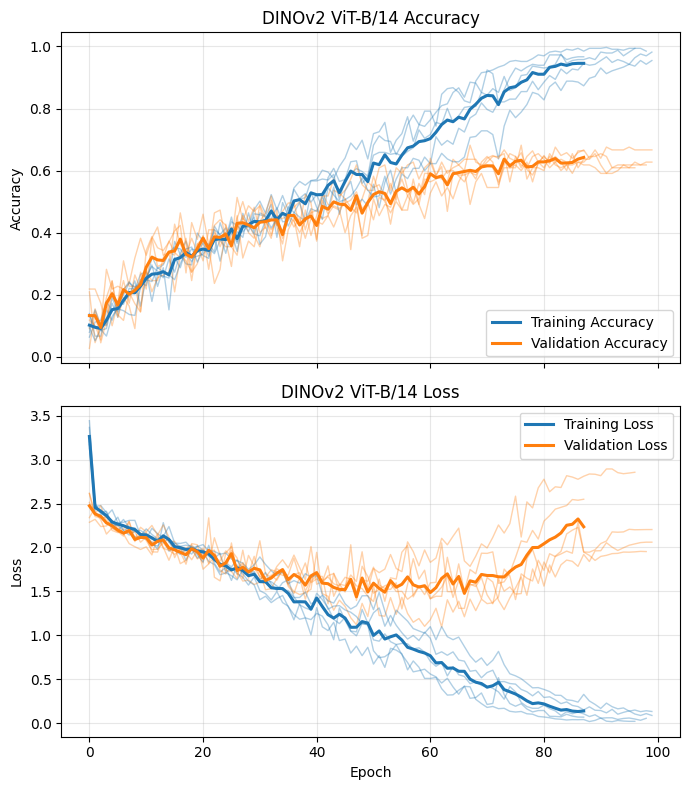

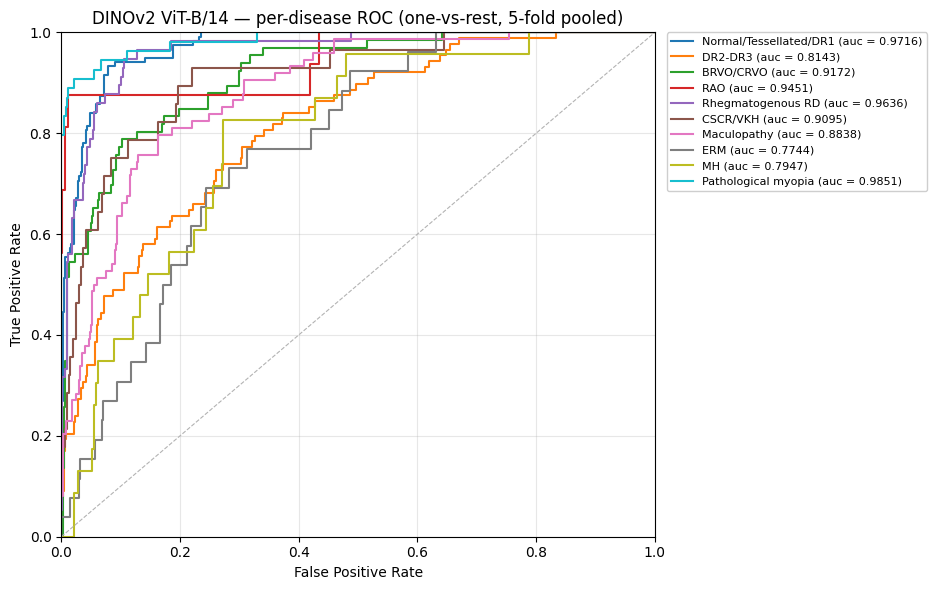


per-class AUC (one-vs-rest, pooled across folds):
  Pathological myopia            0.9851
  Normal/Tessellated/DR1         0.9716
  Rhegmatogenous RD              0.9636
  RAO                            0.9451
  BRVO/CRVO                      0.9172
  CSCR/VKH                       0.9095
  Maculopathy                    0.8838
  DR2-DR3                        0.8143
  MH                             0.7947
  ERM                            0.7744


In [6]:
import os, sys, glob, json, numpy as np, matplotlib.pyplot as plt

# auto-locate fundus_lib + force-reload so newest helpers are picked up
hits = glob.glob("/content/drive/MyDrive/**/fundus_lib/__init__.py", recursive=True)
assert hits
PROJECT_DIR = os.path.dirname(os.path.dirname(hits[0]))
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
for mod in [m for m in list(sys.modules) if m == "fundus_lib" or m.startswith("fundus_lib.")]:
    del sys.modules[mod]
import fundus_lib as fl
import fundus_lib.metrics  # noqa

hist_path = os.path.join(RESULTS_DIR, "history_%s.json" % MODEL_NAME)
if os.path.exists(hist_path):
    histories = json.load(open(hist_path))
    fl.metrics.plot_history(histories, model_name="DINOv2 ViT-B/14",
        save_path=os.path.join(RESULTS_DIR, "history_%s.png" % MODEL_NAME))
    plt.show()
else:
    print("no saved history — re-run the 5-fold cell so train/val loss + accuracy are recorded")

preds = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % MODEL_NAME))
y_true_all, y_prob_all = preds["y_true"], preds["y_prob"]
short = {k: fl.metrics.bigclass_short[k] for k in range(NUM_CLASSES)}
fl.metrics.plot_roc_per_class(
    y_true_all, y_prob_all, index_to_class=short,
    title="DINOv2 ViT-B/14 — per-disease ROC (one-vs-rest, 5-fold pooled)",
    save_path=os.path.join(RESULTS_DIR, "roc_per_class_%s.png" % MODEL_NAME),
)
plt.show()

per_class = fl.metrics.compute_metrics(y_true_all, y_prob_all, index_to_class=short)["per_class_auc"]
print("\nper-class AUC (one-vs-rest, pooled across folds):")
for name, auc in sorted(per_class.items(), key=lambda kv: -kv[1] if not np.isnan(kv[1]) else 0):
    print(f"  {name:30s} {auc:.4f}")


## Grad-CAM: where is DINOv2 ViT-B/14 looking?

Uses `fl.models.gradcam_setup(MODEL_NAME, model)` which returns the right target layer and reshape transform per architecture (last conv block for ResNet; last-block pre-attention LayerNorm + token→spatial reshape for ViT/DINOv2/RETFound).


In [7]:
import os, json, numpy as np, matplotlib.pyplot as plt, torch
from PIL import Image
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

ckpt_path = os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % MODEL_NAME)
build_args = dict()
gradcam_model = fl.models.build_model(MODEL_NAME, NUM_CLASSES, **build_args).to(device)
if "model" in globals() and isinstance(model, torch.nn.Module):
    gradcam_model.load_state_dict(model.state_dict())
    print("using in-memory last-fold model")
elif os.path.exists(ckpt_path):
    gradcam_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print("loaded weights from", ckpt_path)
else:
    raise RuntimeError("no trained model available — re-run training first")
gradcam_model.eval()

target_layers, reshape = fl.models.gradcam_setup(MODEL_NAME, gradcam_model)

last_test_fold = splits["n_splits"] - 1
_, _, te_idx_last = fl.data.fold_indices(folds, last_test_fold)
ds_te = fl.data.FundusDataset(manifest, te_idx_last, eval_tf, c2i)
dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2)
yt, yp = fl.engine.evaluate(gradcam_model, dl_te, device)
y_pred = yp.argmax(1); y_conf = yp.max(1)

short = fl.metrics.bigclass_short
selected = []
for k in range(NUM_CLASSES):
    mask = (yt == k) & (y_pred == k)
    if not mask.any(): continue
    cand = np.where(mask)[0]
    selected.append((int(cand[int(np.argmax(y_conf[cand]))]), int(k)))
print(f"showing {len(selected)} bigclasses (best correct per class, fold {last_test_fold})")

def _prepare(local_i):
    row = ds_te.rows[local_i]
    raw = Image.open(row.get("cache_path", row["path"])).convert("RGB").resize((224, 224))
    rgb = np.asarray(raw, dtype=np.float32) / 255.0
    input_tensor, _ = ds_te[local_i]
    return input_tensor, rgb

cam = GradCAM(model=gradcam_model, target_layers=target_layers, reshape_transform=reshape)

n = len(selected)
fig, axes = plt.subplots(n, 3, figsize=(11, 3.2 * n))
if n == 1: axes = axes.reshape(1, -1)
for r, (li, k) in enumerate(selected):
    input_tensor, rgb = _prepare(li)
    targets = [ClassifierOutputTarget(int(y_pred[li]))]
    heatmap = cam(input_tensor=input_tensor.unsqueeze(0).to(device), targets=targets)[0]
    overlay = show_cam_on_image(rgb, heatmap, use_rgb=True, image_weight=0.75)
    axes[r,0].imshow(rgb); axes[r,0].axis("off")
    axes[r,0].set_title(f"original — {short[k]}", fontsize=9, fontweight="bold")
    axes[r,1].imshow(heatmap, cmap="jet"); axes[r,1].axis("off")
    axes[r,1].set_title(f"Grad-CAM (pred={short[int(y_pred[li])]}, p={y_conf[li]:.2f})", fontsize=9)
    axes[r,2].imshow(overlay); axes[r,2].axis("off")
    axes[r,2].set_title("overlay", fontsize=9)
plt.suptitle(f"DINOv2 ViT-B/14 — Grad-CAM on fold {last_test_fold} test set (best correct per bigclass)",
             fontsize=11, fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "gradcam_%s.png" % MODEL_NAME), dpi=150, bbox_inches="tight")
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## Class balance + per-fold counts

Context for the per-class AUC numbers — a class with 18 images can hit 0.69 AUC just from sampling noise.


In [8]:
import numpy as np
from collections import Counter

short = fl.metrics.bigclass_short
bc_of_idx = np.array([m["bigclass"] for m in manifest])
total = Counter(bc_of_idx.tolist())
per_fold = {f: Counter(bc_of_idx[folds == f].tolist()) for f in range(splits["n_splits"])}

hdr = f'{"bigclass":<26s}{"total":>7s}' + "".join(f'{"fold"+str(f):>7s}' for f in range(splits["n_splits"]))
print(hdr); print("-" * len(hdr))
for k in range(NUM_CLASSES):
    bc = i2c[k]
    row = f'{short[k]:<26s}{total.get(bc,0):>7d}'
    row += "".join(f'{per_fold[f].get(bc,0):>7d}' for f in range(splits["n_splits"]))
    print(row)
print("-" * len(hdr))
tot = f'{"TOTAL":<26s}{sum(total.values()):>7d}'
tot += "".join(f'{sum(per_fold[f].values()):>7d}' for f in range(splits["n_splits"]))
print(tot)


bigclass                    total  fold0  fold1  fold2  fold3  fold4
--------------------------------------------------------------------
Normal/Tessellated/DR1        119     24     24     24     24     23
DR2-DR3                        88     18     18     17     17     18
BRVO/CRVO                      66     13     13     14     13     13
RAO                            16      3      3      3      4      3
Rhegmatogenous RD              57     12     11     11     11     12
CSCR/VKH                       28      5      6      6      6      5
Maculopathy                    74     15     15     15     14     15
ERM                            26      5      5      5      6      5
MH                             23      5      5      4      4      5
Pathological myopia            54     11     10     11     11     11
--------------------------------------------------------------------
TOTAL                         551    111    110    110    110    110


## Confusion matrix (pooled OOF predictions)

Row-normalized (each row sums to 1 = sensitivity for that true class); raw counts in parentheses.


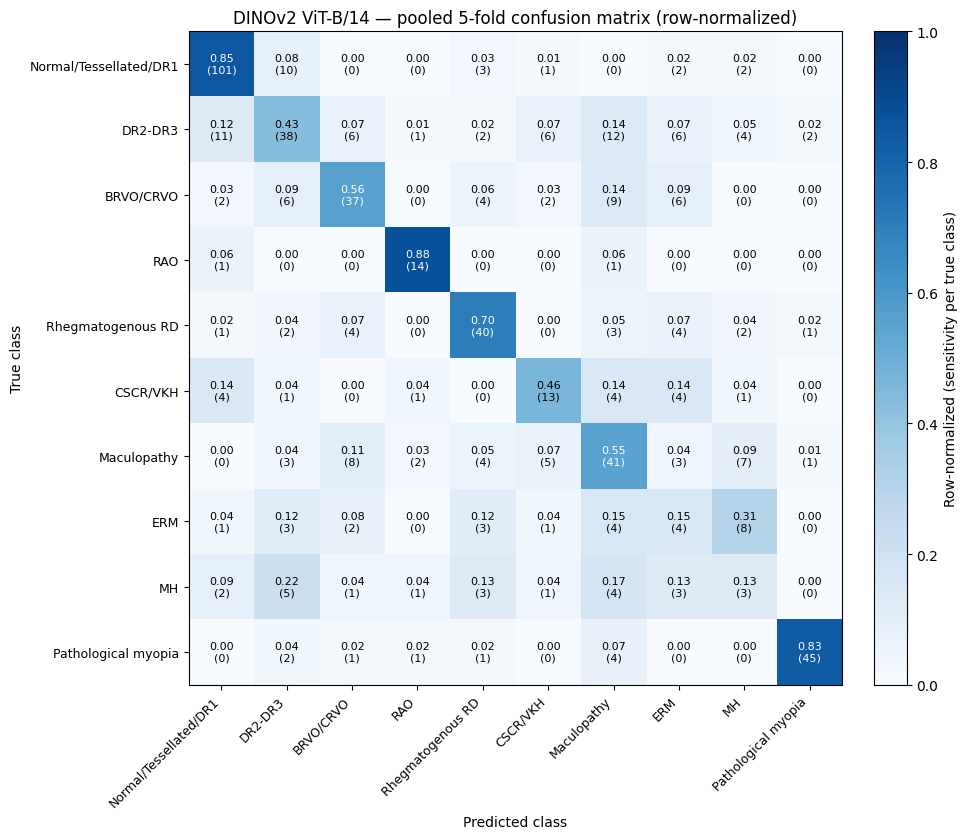

In [9]:
import os, numpy as np, matplotlib.pyplot as plt

preds = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % MODEL_NAME))
y_true_all, y_prob_all = preds["y_true"], preds["y_prob"]
short = fl.metrics.bigclass_short

fl.metrics.plot_confusion_matrix(
    y_true_all, y_prob_all, index_to_class=short, normalize="true",
    title="DINOv2 ViT-B/14 — pooled 5-fold confusion matrix (row-normalized)",
    save_path=os.path.join(RESULTS_DIR, "confusion_%s.png" % MODEL_NAME),
)
plt.show()


## Grad-CAM on failure cases

Highest-confidence wrong predictions in the last fold, target = predicted class (what convinced the model). DeGrave et al. (*Nat Mach Intell* 2021) caught most COVID X-ray classifiers as shortcut-learners this way.


showing top 6 highest-confidence wrong predictions (of 48 failures)


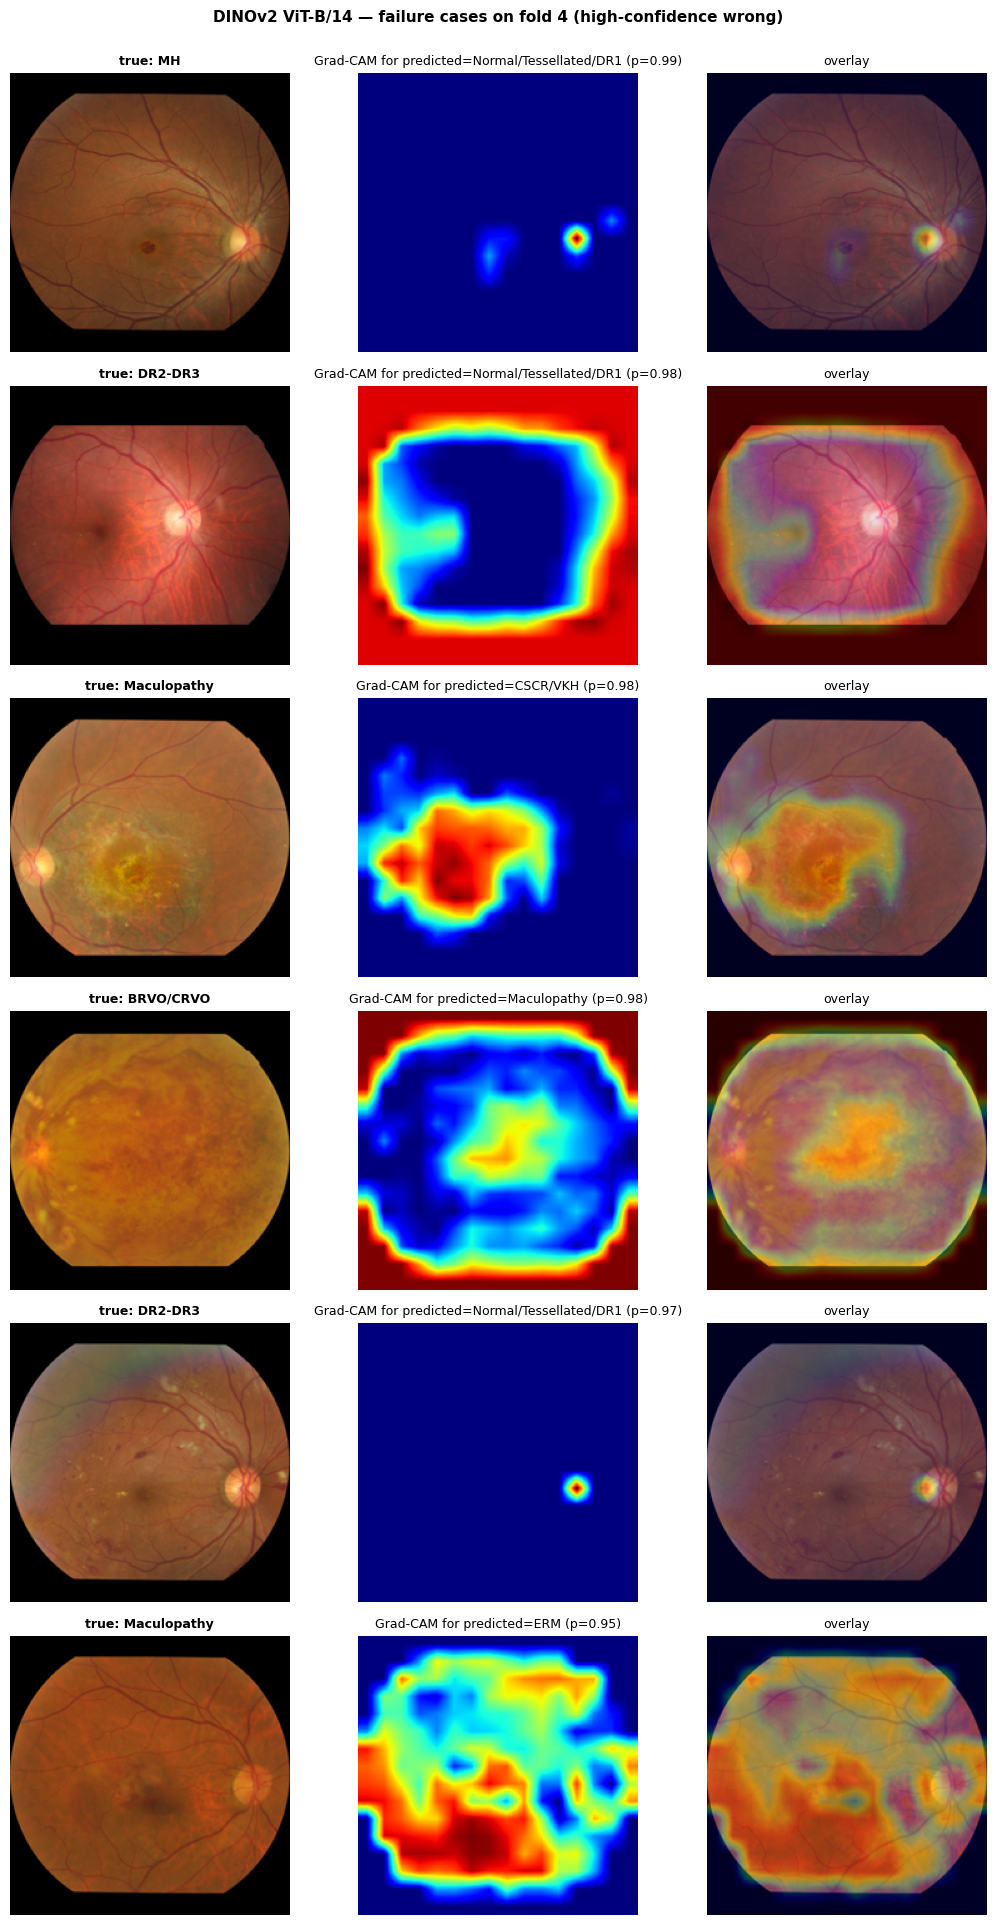

In [10]:
import os, numpy as np, matplotlib.pyplot as plt, torch
from PIL import Image
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

if "gradcam_model" not in globals():
    ckpt_path = os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % MODEL_NAME)
    build_args = dict()
    gradcam_model = fl.models.build_model(MODEL_NAME, NUM_CLASSES, **build_args).to(device)
    if "model" in globals() and isinstance(model, torch.nn.Module):
        gradcam_model.load_state_dict(model.state_dict())
    elif os.path.exists(ckpt_path):
        gradcam_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    else:
        raise RuntimeError("no trained model available")
    gradcam_model.eval()

target_layers, reshape = fl.models.gradcam_setup(MODEL_NAME, gradcam_model)

last_test_fold = splits["n_splits"] - 1
_, _, te_idx_last = fl.data.fold_indices(folds, last_test_fold)
ds_te = fl.data.FundusDataset(manifest, te_idx_last, eval_tf, c2i)
dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2)
yt, yp = fl.engine.evaluate(gradcam_model, dl_te, device)
y_pred = yp.argmax(1); y_conf = yp.max(1)
short = fl.metrics.bigclass_short

wrong = np.where(y_pred != yt)[0]
if len(wrong) == 0:
    print("no failures on the last fold")
else:
    order = wrong[np.argsort(-y_conf[wrong])]
    n_show = min(6, len(order))
    picks = order[:n_show]
    print(f"showing top {n_show} highest-confidence wrong predictions (of {len(wrong)} failures)")

    def _prepare(local_i):
        row = ds_te.rows[local_i]
        raw = Image.open(row.get("cache_path", row["path"])).convert("RGB").resize((224, 224))
        rgb = np.asarray(raw, dtype=np.float32) / 255.0
        input_tensor, _ = ds_te[local_i]
        return input_tensor, rgb

    cam = GradCAM(model=gradcam_model, target_layers=target_layers, reshape_transform=reshape)
    fig, axes = plt.subplots(n_show, 3, figsize=(11, 3.2 * n_show))
    if n_show == 1: axes = axes.reshape(1, -1)
    for r, li in enumerate(picks):
        input_tensor, rgb = _prepare(int(li))
        targets = [ClassifierOutputTarget(int(y_pred[li]))]
        heatmap = cam(input_tensor=input_tensor.unsqueeze(0).to(device), targets=targets)[0]
        overlay = show_cam_on_image(rgb, heatmap, use_rgb=True, image_weight=0.75)
        true_name = short[int(yt[li])]; pred_name = short[int(y_pred[li])]
        axes[r,0].imshow(rgb); axes[r,0].axis("off")
        axes[r,0].set_title(f"true: {true_name}", fontsize=9, fontweight="bold")
        axes[r,1].imshow(heatmap, cmap="jet"); axes[r,1].axis("off")
        axes[r,1].set_title(f"Grad-CAM for predicted={pred_name} (p={y_conf[li]:.2f})", fontsize=9)
        axes[r,2].imshow(overlay); axes[r,2].axis("off")
        axes[r,2].set_title("overlay", fontsize=9)
    plt.suptitle(f"DINOv2 ViT-B/14 — failure cases on fold {last_test_fold} (high-confidence wrong)",
                 fontsize=11, fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "gradcam_failures_%s.png" % MODEL_NAME), dpi=150, bbox_inches="tight")
    plt.show()
